In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
viirs_path = "/home/slow_data/Air_Quality/VIIRS/output/viirs_aod_L2_NOAA20_nearest_filtered.csv"
aeronet_path = "/home/slow_data/Air_Quality/AERONET/NGHIA_DO/aeronet_NGHIA_DO_L15_2022-01-01_2026-04-01.csv"

In [54]:
viirs_df = pd.read_csv(viirs_path)
aeronet_df = pd.read_csv(aeronet_path)

In [55]:
viirs_df
viirs_df['datetime'] = pd.to_datetime(viirs_df['datetime'], errors='coerce')

In [56]:
aeronet_df['datetime'] = pd.to_datetime(
    aeronet_df['Date(dd:mm:yyyy)'] + ' ' + aeronet_df['Time(hh:mm:ss)'],
    format='%d:%m:%Y %H:%M:%S',
    errors='coerce'
)

In [57]:
def compute_aod_550(df):
    df = df.copy()
    
    # convert về numeric
    for col in ['AOD_440nm', 'AOD_500nm', 'AOD_551nm', 'AOD_870nm']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Ångström exponent (ưu tiên dùng sẵn nếu có)
    if '440-870_Angstrom_Exponent' in df.columns:
        alpha = pd.to_numeric(df['440-870_Angstrom_Exponent'], errors='coerce')
    else:
        # fallback: tự tính từ 440 và 870
        alpha = -np.log(df['AOD_440nm'] / df['AOD_870nm']) / np.log(440/870)
    
    df['alpha'] = alpha
    
    # ✅ nếu đã có AOD_551nm → dùng luôn
    df['AOD_550nm'] = df['AOD_551nm']
    
    # ❗ nếu thiếu thì nội suy từ 500nm
    mask_500 = df['AOD_550nm'].isna() & df['AOD_500nm'].notna()
    df.loc[mask_500, 'AOD_550nm'] = df.loc[mask_500, 'AOD_500nm'] * (550/500) ** (-df.loc[mask_500, 'alpha'])
    
    # ❗ fallback tiếp: từ 440nm
    mask_440 = df['AOD_550nm'].isna() & df['AOD_440nm'].notna()
    df.loc[mask_440, 'AOD_550nm'] = df.loc[mask_440, 'AOD_440nm'] * (550/440) ** (-df.loc[mask_440, 'alpha'])
    
    return df

In [58]:
aeronet_df = compute_aod_550(aeronet_df)

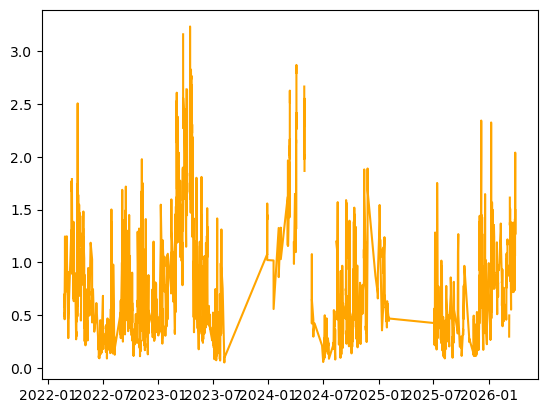

In [59]:
plt.figure()
plt.plot(aeronet_df['datetime'], aeronet_df['AOD_550nm'],
                 color='orange', linewidth=1.5, label='AERONET')
plt.show()

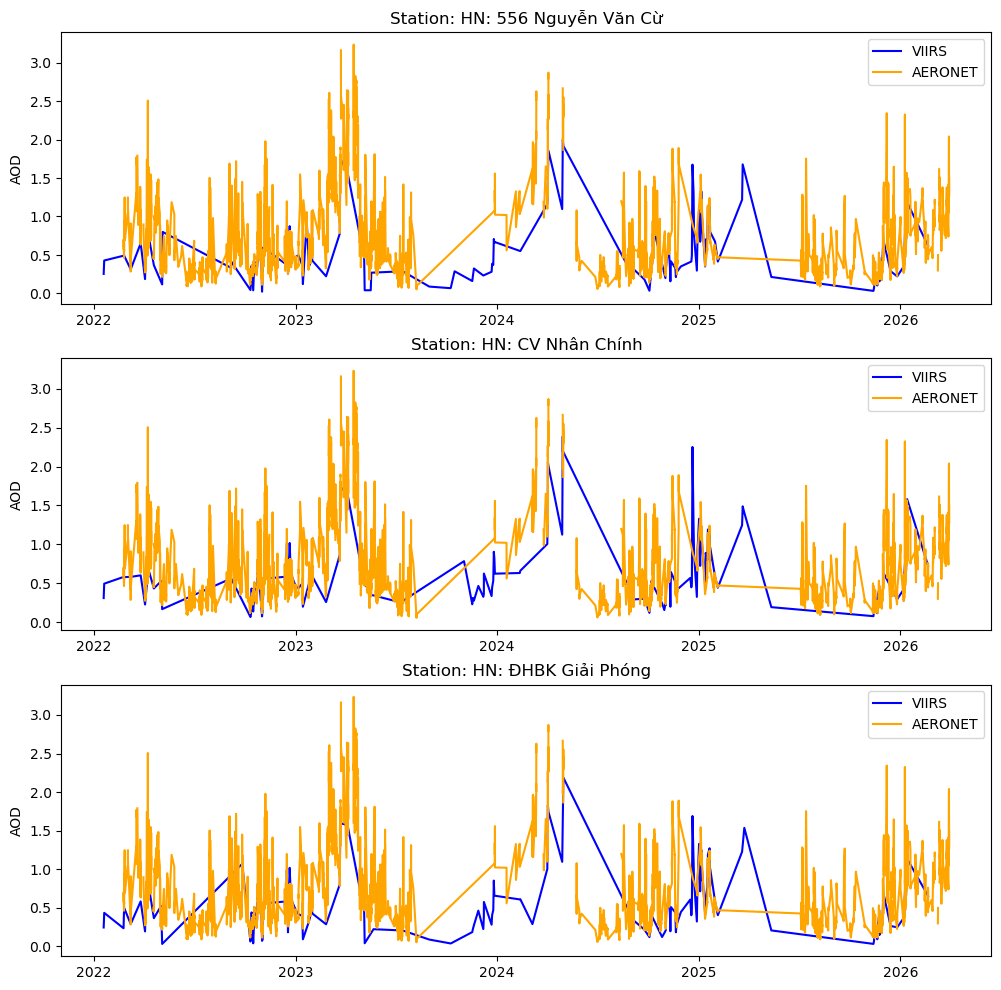

In [62]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)

stations = viirs_df['station'].unique()[:3]

for i, station in enumerate(stations):
    viirs_subset = viirs_df[viirs_df['station'] == station].sort_values('datetime')

    axes[i].plot(viirs_subset['datetime'], viirs_subset['aod'],
                 color='blue', linewidth=1.5, label='VIIRS')

    axes[i].plot(aeronet_df['datetime'], aeronet_df['AOD_550nm'],
                 color='orange', linewidth=1.5, label='AERONET')

    axes[i].set_title(f"Station: {station}")
    axes[i].set_ylabel('AOD')

    axes[i].legend()

    axes[i].xaxis.set_major_locator(mdates.YearLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))